## Applicability Across Tracking Points

This notebook supports the "Applicability Across Tracking Points" subsection of the manuscript, in two parts:

- **Part B (first):** for every one of the 8 available tracking points, what fraction of simulated project realisations end in delay. This determines *which* tracking points can meaningfully support counterfactual recourse at all — a counterfactual that flips the prediction to "on time" can only exist if on-time outcomes are actually reachable within the modelled uncertainty bounds.
- **Part A (second):** having identified TP2 (28.73% EV) as the latest tracking point that still retains genuine outcome uncertainty, we repeat the full pipeline there — fine-grained simulation, instance selection, surrogate retraining, SHAP, and DiCE counterfactual generation — and compare the result against the TP1 case reported in the manuscript's main case study.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import ast
import time
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

import shap
import dice_ml

from tools import extract_hours, pert_sample, draw_random_durations, compute_times, find_critical_path, simulation

my_seed = 42
np.random.seed(my_seed)
sns.set_theme(palette='tab10')

### Build the AON network (same as `monte_carlo_simulation.ipynb`)

In [2]:
project_name = 'C2019-05_Fuel_Tank_Filter'
file_path = '../input_data/C2019-05 Fuel Tank Filter.xlsx'
Nca = 10  # Number of control accounts (tracking points)

# Baseline schedule
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    df = pd.read_excel(file_path, sheet_name='Baseline Schedule', skiprows=1, index_col=0, usecols='A:N')
df.drop(0, axis=0, inplace=True)
df.drop(df[df['Successors'].isna() & df['Predecessors'].isna()].index, axis=0, inplace=True)
df['DurationH'] = df['Duration'].apply(lambda x: extract_hours(x))
df_project = df[['Name', 'Successors', 'DurationH', 'Total Cost']].copy()
df_project.columns = ['Name', 'Successors', 'Duration', 'TotalCost']

OPT, MP, PE = 0.8, 1.1, 1.2
df_project['Optimistic'] = df_project['Duration'] * OPT
df_project['MostProbable'] = df_project['Duration'] * MP
df_project['Pessimistic'] = df_project['Duration'] * PE

Go = nx.DiGraph()
for i in df_project.index:
    mean_d = (df_project.loc[i, 'Optimistic'] + 4 * df_project.loc[i, 'MostProbable'] + df_project.loc[i, 'Pessimistic']) / 6
    Go.add_node(i,
                planned_value=df_project.loc[i, 'TotalCost'],
                duration0=df_project.loc[i, 'Duration'],
                optimistic=df_project.loc[i, 'Optimistic'],
                pessimistic=df_project.loc[i, 'Pessimistic'],
                mostlikely=df_project.loc[i, 'MostProbable'],
                mean_duration=mean_d)
    if not pd.isna(df_project.loc[i, 'Successors']):
        for s in df_project.loc[i, 'Successors'].split(";"):
            Go.add_edge(i, int(s[2:]), type=s[:2])

print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges, DAG: {nx.is_directed_acyclic_graph(Go)}')

AON graph with 15 nodes and 23 edges, DAG: True


## Part B — Which tracking points admit actionable counterfactuals?

Reuses the coarse ($N_s=1{,}000$) per-tracking-point simulations already produced by `monte_carlo_simulation.ipynb` (`../sim_data/C2019-05_Fuel_Tank_Filter/`) — no new simulation needed for this part. For each tracking point, we compute the fraction of simulated realisations that end up delayed relative to the baseline duration.

TP7 is excluded: it shares the same EV% as TP8 (a duplicate/erroneous entry in the source control-account data, already flagged as such in `monte_carlo_simulation.ipynb`).

In [3]:
siml = [f for f in os.listdir(os.path.join("../sim_data/", project_name)) if f"simulation_{project_name}_tp" in f]
siml = [(int(re.search(r'tp(\d+)', f).group(1)), re.search(r'ev([\d.]+)', f).group(1)[:-1], f) for f in siml]
siml = sorted(siml, key=lambda x: x[0])
siml = [s for s in siml if s[0] != 7]  # duplicate EV% of TP8, excluded

delay_rows = []
for tp, ev, fname in siml:
    df_sim = pd.read_csv(f'../sim_data/{project_name}/{fname}')
    base = df_sim.loc[0, 'baseline_duration']
    pct_delay = (df_sim['actual_duration'] > base).mean() * 100
    delay_rows.append({'TP': tp, 'EV_%': float(ev) * 100, 'delay_probability_%': pct_delay, 'n': len(df_sim)})

delay_table = pd.DataFrame(delay_rows)
delay_table.to_csv('../sim_data/delay_probability_by_tracking_point.csv', index=False)
print(delay_table.to_string(index=False))

 TP   EV_%  delay_probability_%    n
  0   0.00                 75.9 1000
  1  18.12                 70.0 1000
  2  28.73                 78.1 1000
  3  36.14                 99.5 1000
  4  48.65                100.0 1000
  5  62.03                100.0 1000
  6  64.51                100.0 1000
  8  72.00                100.0 1000
  9  80.87                100.0 1000
 10 100.00                100.0 1000


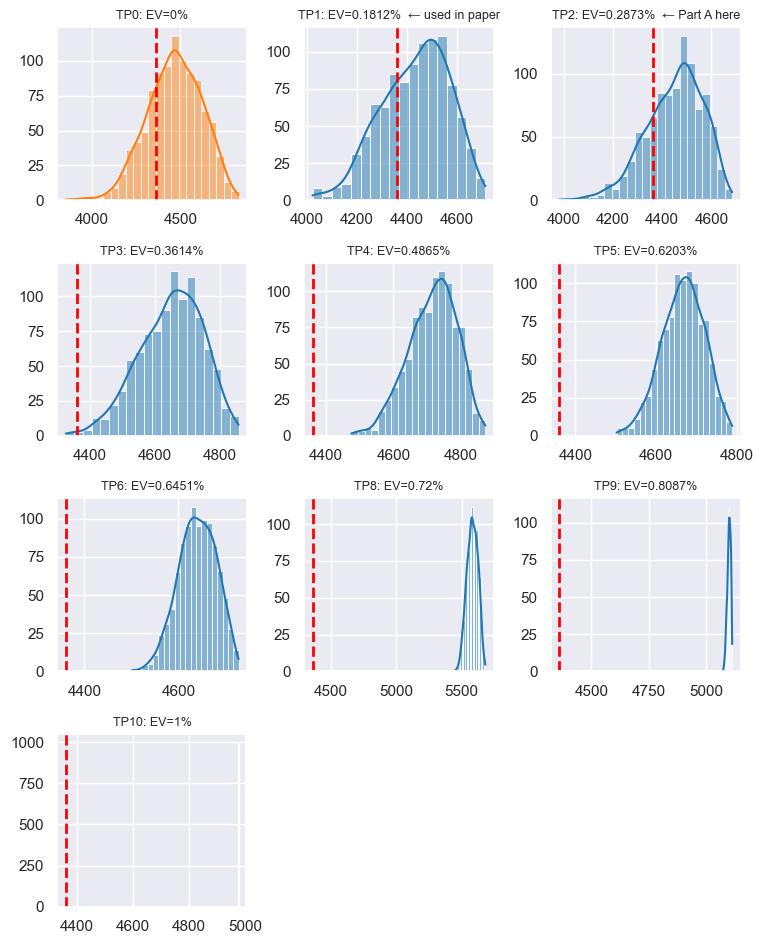

In [4]:
Nr, Nc = Nca // 3 + 1, 3
fig, axes = plt.subplots(Nr, Nc, figsize=(Nc * 2.6, Nr * 2.4))
axes = axes.flatten()

for ax, (tp, ev, fname) in zip(axes, siml):
    df_sim = pd.read_csv(f'../sim_data/{project_name}/{fname}')
    sns.histplot(df_sim['actual_duration'], kde=True, ax=ax,
                 color=sns.color_palette("tab10")[1] if tp == 0 else sns.color_palette("tab10")[0])
    ax.axvline(x=df_sim.loc[0, 'baseline_duration'], color='red', linestyle='--', linewidth=2)
    ax.set_xlabel(''); ax.set_ylabel('')
    label = "EV=0%" if tp == 0 else f"EV={ev}%"
    ax.set_title(f"TP{tp}: {label}" + ("  ← used in paper" if tp == 1 else "  ← Part A here" if tp == 2 else ""),
                 fontsize=9)
for ax in axes[len(siml):]:
    ax.axis('off')
plt.tight_layout()
# Diagnostic only -- not a manuscript figure (Part B is reported as a table), so not saved to ../figures/.
plt.show()

**Conclusion (Part B).** Given the PERT bounds used to model task-duration uncertainty (optimistic $0.8\times$, pessimistic $1.2\times$ the baseline), the outcome is already virtually certain by TP3 (36.14% EV, 99.5% of realisations delayed) and fully deterministic from TP4 (48.65% EV) onward — no combination of remaining-task durations within the modelled optimistic bounds can still recover an on-time completion, so no "on-time" counterfactual can exist for DiCE to search for at those tracking points. TP2 (28.73% EV) is the latest tracking point that still retains genuine outcome uncertainty (78.1% delayed / 21.9% on time) comparable in kind to TP1 (70.0% delayed / 30.0% on time) — this is why TP2, not a later point, is used for the Part A comparison below.

## Part A — Full pipeline rerun at TP2

### Step 1: Fine-grained simulation at TP2 ($N_s=25{,}000$)

Mirrors exactly what `monte_carlo_simulation.ipynb` did for TP1 ("Monte Carlo Simulation for the Tracking Point EV=18%" section), but for `tp=2`.

In [5]:
tp = 2
Ns = 25000
start_time = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    df_tp = pd.read_excel(file_path, sheet_name='TP' + str(tp), skiprows=3, index_col=0)
ev_percent = df_tp.loc[0, 'Percentage Completed']
dfc = df_tp.loc[df_tp.index.intersection(Go.nodes()),
                ['Actual Duration', 'Actual Cost', 'Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
dfc['Actual Duration'] = dfc['Actual Duration'].apply(lambda x: extract_hours(x))
dfc.columns = ['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue']

print(f'Simulating TP{tp} (EV={ev_percent*100:.2f}%) with Ns={Ns} ...')
simulation(Go.copy(), project_name='C201905_counterfactuals_tp2', experiment='_ev' + str(round(ev_percent, 4)),
           control=dfc, Nruns=Ns)
print(f'Done in {time.time() - start_time:.1f}s')

Simulating TP2 (EV=28.73%) with Ns=25000 ...


Done in 12.5s


### Step 2: Query instance selection at TP2

Same method as `selection_of_instance.ipynb`: standardize, k-means with $k$ chosen by silhouette score over $k\in[2,10]$, take the majority cluster, and pick the instance closest to its centroid.

In [6]:
data_tp2 = pd.read_csv(f'../sim_data/C201905_counterfactuals_tp2/simulation_C201905_counterfactuals_tp2__ev{round(ev_percent,4)}.csv', index_col=0)
data_tp2['delay'] = (data_tp2['actual_duration'] > data_tp2['baseline_duration']) * 1
data_tp2.drop(columns=['actual_duration', 'baseline_duration', 'critical_path'], inplace=True)
columns_sorted = sorted(data_tp2.columns, key=lambda x: int(x.replace('duration', '')) if 'duration' in x else float('inf'))
data_tp2 = data_tp2[columns_sorted]

numeric_cols = data_tp2.select_dtypes(include='number').columns
X_cluster = StandardScaler().fit_transform(data_tp2[numeric_cols])

k_range = range(2, 11)
silhouette_scores = [silhouette_score(X_cluster, KMeans(n_clusters=k, random_state=my_seed).fit_predict(X_cluster)) for k in k_range]
best_k = k_range[int(np.argmax(silhouette_scores))]
print(f'Best k by silhouette score: {best_k}')

kmeans = KMeans(n_clusters=best_k, random_state=my_seed)
data_tp2_c = data_tp2.copy()
data_tp2_c['cluster'] = kmeans.fit_predict(X_cluster)

majority_cluster = data_tp2_c['cluster'].value_counts().idxmax()
mask = data_tp2_c['cluster'] == majority_cluster
cluster_data = X_cluster[mask]
centroid = kmeans.cluster_centers_[majority_cluster]
distances = np.linalg.norm(cluster_data - centroid, axis=1)
representative_index = data_tp2_c[mask].iloc[distances.argmin()].name

print(f'Query instance index at TP2: {representative_index}')
print(f"Majority cluster mean delay rate: {data_tp2_c.groupby('cluster')['delay'].mean().loc[majority_cluster]:.2f}")
print(data_tp2.loc[[representative_index]])

Best k by silhouette score: 2
Query instance index at TP2: 24581
Majority cluster mean delay rate: 1.00
         duration1    duration2  duration3    duration4    duration5  \
24581  1926.732143  1728.568513  460.80314  2224.332572  1902.940558   

         duration6    duration7    duration8    duration9   duration10  \
24581  2084.953993  2230.208626  1665.753423  2130.813184  2339.828687   

        duration11  duration12  duration13  duration14  duration15  delay  
24581  2310.497404  136.478207    8.617542  226.071563    8.495853      1  


### Step 3: Retrain the surrogate model on TP2 data

Reusing the TP1-trained model directly on TP2 data does not work: its scaler puts several TP2 task durations outside the $[0,1]$ range it was fit on (TP2 has more tasks with real, completed durations that fall outside the simulated TP1 envelope), and its accuracy on TP2 drops to 61.6% while badly under-predicting delay (39.7% predicted vs. 78.1% actual). We therefore refit both the scaler and the model on TP2's own data, reusing the **same hyperparameters** already selected for TP1 in `model_selection.ipynb` (`GradientBoostingClassifier(max_depth=5, n_estimators=100)`) rather than repeating the full `GridSearchCV` search.

In [7]:
X_tp2 = data_tp2.drop(columns=['delay'])
y_tp2 = data_tp2['delay']

scaler_tp2 = MinMaxScaler().fit(X_tp2)
X_tp2_norm = pd.DataFrame(scaler_tp2.transform(X_tp2), columns=X_tp2.columns, index=X_tp2.index)

gbc_tp2 = GradientBoostingClassifier(max_depth=5, n_estimators=100, random_state=my_seed)
gbc_tp2.fit(X_tp2_norm, y_tp2)

train_acc = accuracy_score(y_tp2, gbc_tp2.predict(X_tp2_norm))
print(f'GBC (TP2) training accuracy: {train_acc*100:.3f}%')

query_instance_tp2 = X_tp2_norm.loc[[representative_index]]
class_of_query_instance_tp2 = y_tp2.loc[[representative_index]]
print('Query instance class (1=delay):', class_of_query_instance_tp2.values)
print('Model prediction:', gbc_tp2.predict(query_instance_tp2))

joblib.dump(gbc_tp2, '../models/gbc_tp2_model.pkl')

GBC (TP2) training accuracy: 99.908%
Query instance class (1=delay): [1]
Model prediction: [1]


['../models/gbc_tp2_model.pkl']

### Step 4: SHAP + DiCE counterfactual generation at TP2

SHAP analysis of the TP2 query instance, then the same **6 GBC-based DiCE configurations** used for GBC in `cfs_generation.ipynb` (random, KDTree, KDTree with binary sparsity=1, genetic default, genetic with sparsity=1, genetic with tuned proximity/diversity), expressed as a loop instead of the original's copy-pasted cells.

In [8]:
explainer_tp2 = shap.Explainer(gbc_tp2, X_tp2_norm)
shap_values_tp2 = explainer_tp2(query_instance_tp2)

vals = shap_values_tp2.values
if vals.ndim == 3:
    vals = vals[:, :, 1]
vals = vals[0]

shap_ranking_tp2 = pd.Series(vals, index=X_tp2_norm.columns).sort_values(ascending=False)
print('SHAP ranking towards delay at TP2 (highest first):')
print(shap_ranking_tp2)

SHAP ranking towards delay at TP2 (highest first):
duration11    1.586002
duration10    0.817592
duration1     0.566743
duration15    0.047434
duration3     0.025813
duration4     0.001079
duration9     0.000052
duration6     0.000000
duration2    -0.000099
duration7    -0.000159
duration5    -0.002911
duration13   -0.012089
duration8    -0.029612
duration12   -0.038687
duration14   -0.323950
dtype: float64


In [9]:
duration_cols_tp2 = [f'duration{i}' for i in range(1, 16)]
# DiCE's data_interface must be built from the SAME (normalized) space the model and the
# query instance live in -- using the raw dataframe here mismatches ranges and silently
# breaks the "random" method's search (kdtree/genetic happened to still succeed regardless).
data_for_dice_tp2 = pd.concat([X_tp2_norm, y_tp2], axis=1)
d_tp2 = dice_ml.Data(dataframe=data_for_dice_tp2, continuous_features=duration_cols_tp2, outcome_name='delay')
m_gbc_tp2 = dice_ml.Model(model=gbc_tp2, backend="sklearn")

def denormalize(df_norm, scaler, cols):
    return pd.DataFrame(scaler.inverse_transform(df_norm[cols]), columns=cols, index=df_norm.index)

def gen_cfs(explainer, label, method_name, proximity, diversity, sparsity_label, **kwargs):
    cfs = explainer.generate_counterfactuals(query_instance_tp2, total_CFs=10, desired_class="opposite", **kwargs)
    cf_df = cfs.cf_examples_list[0].final_cfs_df
    denorm = denormalize(cf_df, scaler_tp2, duration_cols_tp2)
    denorm['delay'] = cf_df['delay'].values
    denorm['subrogate_model'] = 'GradientBoosting'
    denorm['method'] = method_name
    denorm['proximity'] = proximity
    denorm['diversity'] = diversity
    denorm['sparsity'] = sparsity_label
    print(f'{label}: generated {len(denorm)} CFs')
    return denorm

gbc_random_tp2  = dice_ml.Dice(data_interface=d_tp2, model_interface=m_gbc_tp2, method="random")
gbc_kdtree_tp2  = dice_ml.Dice(data_interface=d_tp2, model_interface=m_gbc_tp2, method="kdtree")
gbc_genetic_tp2 = dice_ml.Dice(data_interface=d_tp2, model_interface=m_gbc_tp2, method="genetic")

results = []
results.append(gen_cfs(gbc_random_tp2, 'random', 'MA - Random', 0.5, 1, '0.1 linear'))
results.append(gen_cfs(gbc_kdtree_tp2, 'kdtree', 'KDTree', 0.5, 1, '0.1 linear'))
results.append(gen_cfs(gbc_kdtree_tp2, 'kdtree sw1 binary', 'KDTree', 0.5, 1, '1 binary',
                        posthoc_sparsity_param=1, posthoc_sparsity_algorithm='binary'))
results.append(gen_cfs(gbc_genetic_tp2, 'genetic default', 'Genetic', 0.5, 1, '0.2'))

gbc_genetic_tp2.update_hyperparameters(proximity_weight=0.5, sparsity_weight=1, diversity_weight=1, categorical_penalty=0.1)
results.append(gen_cfs(gbc_genetic_tp2, 'genetic sw1', 'Genetic', 0.5, 1, '1'))

gbc_genetic_tp2.update_hyperparameters(proximity_weight=1, sparsity_weight=1, diversity_weight=0.5, categorical_penalty=0.1)
results.append(gen_cfs(gbc_genetic_tp2, 'genetic pw1 dw0.5', 'Genetic', 1, 0.5, '1'))

comparison_df_tp2 = pd.concat(results, ignore_index=True)
print(f'\nTotal raw candidates at TP2: {len(comparison_df_tp2)}')

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  6.48it/s]

100%|██████████| 1/1 [00:00<00:00,  6.47it/s]

random: generated 10 CFs


  0%|          | 0/1 [00:00<?, ?it/s]

...

genetic sw1: generated 10 CFs


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  9.32it/s]

100%|██████████| 1/1 [00:00<00:00,  9.29it/s]

genetic pw1 dw0.5: generated 10 CFs

Total raw candidates at TP2: 60


### Step 5: Cost, ranking, and comparison with TP1

Same cost function (Equation 1 in the manuscript, $\alpha=0.1$, $\beta=0$) and the same task cost rates / baseline durations — these are fixed properties of the project, not of the tracking point.

In [10]:
def calculate_project_cost(instance_duration, base_duration, linear_cost, alpha, beta):
    d = instance_duration.squeeze()
    d_base = base_duration.squeeze()
    c = linear_cost.squeeze()
    d_optimistic = d_base * 0.8
    d_pessimistic = d_base * 1.2
    cost = pd.Series(index=d.index, dtype=float)
    for task in d.index:
        if d[task] < d_base[task]:
            denominator = (d_base[task] - d_optimistic[task]) ** 2
            adjustment = 1 + alpha * (d_base[task] - d[task]) / denominator if denominator != 0 else 1
        else:
            denominator = (d_pessimistic[task] - d_base[task]) ** 2
            adjustment = 1 + beta * (d[task] - d_base[task]) / denominator if denominator != 0 else 1
        cost[task] = d[task] * c[task] * adjustment
    return cost.sum()

costs = [122.77, 151.32, 291.67, 67.88, 2.82, 49.07, 75.00, 6.19, 37.45, 7.90, 9.21, 1554.69, 0.00, 921.30, 0.00]
df_costs = pd.DataFrame([costs], columns=[f"duration{i+1}" for i in range(15)])
base_durations_days = [224, 209, 30, 267, 222, 242, 250, 202, 247, 269, 258, 16, 1, 27, 1]
base_durations_hours = pd.DataFrame([base_durations_days], columns=[f"duration{i+1}" for i in range(15)]) * 8
alpha, beta = 0.1, 0

comparison_df_tp2['cost'] = comparison_df_tp2[duration_cols_tp2].apply(
    lambda row: calculate_project_cost(row.to_frame().T, base_durations_hours, df_costs, alpha, beta), axis=1)
comparison_df_tp2_sorted = comparison_df_tp2.sort_values('cost').drop_duplicates(
    subset=duration_cols_tp2, keep='first').reset_index(drop=True)
comparison_df_tp2_sorted['CF_ID'] = range(1, len(comparison_df_tp2_sorted) + 1)

top5_tp2 = comparison_df_tp2_sorted.head(5)[['CF_ID', 'cost', 'method', 'sparsity']]
top5_tp2.to_csv('../sim_data/comparison_df_tp2_sorted.csv', index=False)
print(f'Unique candidate pool at TP2: {len(comparison_df_tp2_sorted)} (from {len(comparison_df_tp2)} raw)')
print(top5_tp2.to_string(index=False))

Unique candidate pool at TP2: 22 (from 60 raw)
 CF_ID         cost      method   sparsity
     1 1.590501e+06     Genetic          1
     2 1.591103e+06 MA - Random 0.1 linear
     3 1.592409e+06 MA - Random 0.1 linear
     4 1.594751e+06 MA - Random 0.1 linear
     5 1.594891e+06 MA - Random 0.1 linear


In [11]:
query_denorm_tp2 = denormalize(query_instance_tp2, scaler_tp2, duration_cols_tp2)
query_cost_tp2 = calculate_project_cost(query_denorm_tp2, base_durations_hours, df_costs, alpha, beta)
best_cf_tp2 = comparison_df_tp2_sorted.iloc[0]
best_cf_cost_tp2 = best_cf_tp2['cost']
savings_tp2 = (query_cost_tp2 - best_cf_cost_tp2) / query_cost_tp2 * 100

print(f'TP2 query instance cost:        {query_cost_tp2:,.2f}')
print(f'TP2 best counterfactual cost:   {best_cf_cost_tp2:,.2f}  ({best_cf_tp2["method"]}, sparsity={best_cf_tp2["sparsity"]})')
print(f'TP2 saving vs. query instance:  {savings_tp2:.2f}%')
print()
print('--- For comparison, TP1 (published, Table 3) ---')
print('TP1 CF1 cost: 1,467,445.33  |  saving vs. query instance: 3.5%')
print()

changed = query_denorm_tp2.iloc[0].astype(float)
best_vals = best_cf_tp2[duration_cols_tp2].astype(float)
pct_change = ((best_vals - changed) / changed * 100).round(1)
touched = pct_change[pct_change.abs() > 0.5].sort_values()
print('TP2 best CF — tasks touched (% change vs. TP2 query instance):')
print(touched)

TP2 query instance cost:        1,608,778.00
TP2 best counterfactual cost:   1,590,501.41  (Genetic, sparsity=1)
TP2 saving vs. query instance:  1.14%

--- For comparison, TP1 (published, Table 3) ---
TP1 CF1 cost: 1,467,445.33  |  saving vs. query instance: 3.5%

TP2 best CF — tasks touched (% change vs. TP2 query instance):
duration12   -7.2
duration11   -5.2
duration10   -5.0
duration1    -1.7
duration4    -1.7
duration9     1.3
duration14    2.5
duration13    2.7
duration15    3.9
duration8     4.6
dtype: float64


**Summary.** At TP2, the query instance itself already costs more than TP1's (1,608,778 vs. ≈1,520,564) — later in the project, more cost is already sunk into completed/actual task durations. More importantly, the *achievable saving* from the best counterfactual shrinks from 3.5% (TP1) to 1.14% (TP2): as the project progresses, less of the schedule remains free to optimise, so there is genuinely less room for corrective action, independent of which specific tasks are recommended. The TP2 best counterfactual also spreads its changes across 10 tasks (a "diversified" strategy) rather than TP1's 2 (a "sparse" one) — though this specific contrast should be read with the caveat that TP2 draws only from GBC-based DiCE configurations (6, vs. TP1's 11 across GBC+TensorFlow), a smaller and less diverse candidate pool by design (see the scope discussion earlier in this notebook).